# ДЗ-2 по Теории и практике онлайн экспериментов

### Задание 1 (1.5 балла)

В приложенном файле `sleep.csv` приведено время засыпания одного и того же человека в разные дни.

Нужно обработать эти данные и указать такое время суток (с точностью до минуты), после которого с вероятностью 0.9 этот человек уже спит.

Как можно оценить стандартное отклонение этой точечной оценки?

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
df = pd.read_csv('sleep.csv')
df['Unnamed: 0'] = pd.to_datetime(df['Unnamed: 0'])
df['date'] = df['Unnamed: 0'].dt.date
filtered_df = df[df['indicator'] == 1]
first_sleep_time = filtered_df.groupby('date').first()
df = first_sleep_time[['Unnamed: 0', 'time_offset']]
df

,Unnamed: 0,time_offset
date,,
2017-12-01,2017-12-01 22:16:00,16
2017-12-02,2017-12-02 22:19:00,19
2017-12-03,2017-12-03 21:15:00,-45
2017-12-04,2017-12-04 22:08:00,8
2017-12-05,2017-12-05 21:37:00,-23
...,...,...
2018-01-28,2018-01-28 22:09:00,9
2018-01-29,2018-01-29 21:46:00,-14
2018-01-30,2018-01-30 21:59:00,-1


In [3]:
df_quantile = df['time_offset'].quantile(0.9)
filtered_df = df[df['time_offset'] >= df_quantile]
bootstrap = []

for i in range(1000):
        values = np.random.choice(filtered_df['time_offset'], size=63, replace=True)
        bootstrap.append(np.quantile(values, 0.9))

std = np.std(bootstrap)

time_str = '22:00:00'
time_datetime = pd.to_datetime(time_str)
new_time = time_datetime + pd.Timedelta(minutes=int(df_quantile))
formatted_new_time = new_time.strftime('%H:%M:%S') 

print('90% квантиль:', df_quantile)
print('Стандартное отклонение для 90% квантиля:', std)
print('Время после которого человек спит', formatted_new_time)

90% квантиль: 46.0
Стандартное отклонение для 90% квантиля: 8.500145655222623
Время после которого человек спит 22:46:00


-----------
Представим, что у нас есть сервис для продажи некоторых товаров (например, мыла). Мы выкатываем новые фичи и проводим тесты, а затем сохраняем логи каждого теста в следующем формате:

- `user_id` - уникальный id посетителя сайта
- `dt` - дата события
- `event` - название события
- `group` - группа, в которую попал пользователь (распределение может происходить на разных этапах воронки для разных тестов - например, при первом посещении или при первом добавлении в корзину)
- `visit_id` - уникальный id визита
- `cart_id` - уникальный id корзины
- amount - текущая сумма корзины
- `num_items` - текущее количество товаров в корзине

### Задание 2 (0.5 балла)

Мы сделали рекомендательную систему, которая после добавления товара в корзину предлагает добавить похожие или комплементарные. Логи проведенного теста сохранены в файле `ab_test_logs.pkl`. Проверьте гипотезу о том, что в тестовой группе для 70% пользователей выросла выручка (revenue per user).

In [4]:
df = pd.read_pickle('ab_test_logs (1).pkl')
df_paid = df[df['event'] == 'cart-paid']
df_paid_set = set(df_paid['cart_id'])
df = df[df['cart_id'].isin(df_paid_set)]
df = df[~df['group'].isna()]
df = df[~df['amount'].isna()]
df

,user_id,dt,event,group,visit_id,cart_id,amount,num_items
8,6W79RT,2024-01-22,cart-add,test,84k1tk4iugavhadkbai7,zd6s005p6q,673.411454,6.0
26,6ZODD2,2024-01-14,cart-add,test,qg3pn8x6528gnj0fssli,kl2m6tttzu,2306.844187,3.0
44,HGB07Y,2024-01-20,cart-add,control,w0dqqpccye8ny7m6gm3s,p9yd3iyi12,618.221124,1.0
61,9B1GZX,2024-01-22,cart-add,control,85u40ru1muvoub340t8t,d8ntbphfv3,189.754329,1.0
65,R4PIFY,2024-01-18,cart-add,control,m8yqrrdz7f3u5zz8lyc7,zotdvzlit9,2120.598399,1.0
...,...,...,...,...,...,...,...,...
51281,WQW20A,2024-01-24,cart-add,control,hym7i88vg2zh1rs5j5ma,bmr2mr2m4k,1289.643480,1.0
51286,IMVZ1G,2024-01-20,cart-add,control,9djqjw2ptaz685huqv6p,syjyxffysq,370.869260,1.0
51298,PEDE56,2024-01-17,cart-add,control,kff1w8rrobjzbhb68gvb,d5q14sc7o6,5596.670931,7.0
51315,KWV5WA,2024-01-18,cart-add,control,g60y5g05nt2j95j4fe1f,4n0rsdiq64,468.828448,1.0


In [5]:
df['revenue'] = df['amount'].astype(float)*df['num_items'].astype(int)
print('Средняя выручка в тесте:', df[df['group'] == 'test']['revenue'].mean(), 
      'Средняя выручка в контроле:', df[df['group'] == 'control']['revenue'].mean())

Средняя выручка в тесте: 6913.695548931154 Средняя выручка в контроле: 6382.026944684629


In [6]:
grouped = df.groupby(['user_id', 'group']).agg(
    total_amount=pd.NamedAgg(column='amount', aggfunc='sum'),
    count=pd.NamedAgg(column='amount', aggfunc='count')
).reset_index()

grouped['avg_check'] = grouped['total_amount']/grouped['count']


#удалим дубликаты юзеров
users = grouped.groupby('user_id')['group'].unique().reset_index()
users_with_both = users[users['group'].apply(lambda x: 'test' in x and 'control' in x)]['user_id']
filtered_df = grouped[~grouped['user_id'].isin(users_with_both)]
filtered_df

,user_id,group,total_amount,count,avg_check
0,01ZW0R,test,5853.584375,1,5853.584375
1,02CQJP,control,1001.403828,1,1001.403828
2,02QS9O,control,177.672692,1,177.672692
5,04RYQW,test,9910.717453,1,9910.717453
6,05TM9T,control,329.382022,1,329.382022
...,...,...,...,...,...
1820,ZXS8UT,test,301.766633,1,301.766633
1821,ZXX9UM,control,1727.314208,1,1727.314208
1822,ZZ55D1,test,265.327179,1,265.327179
1823,ZZ804D,control,2475.438353,1,2475.438353


In [7]:
print(filtered_df[filtered_df['group'] == 'test']['user_id'].nunique())
print(filtered_df[filtered_df['group'] == 'control']['user_id'].nunique())

902
809


In [8]:
#разделим датасет на тест и контроль
test = filtered_df[filtered_df['group'] == 'test']
control = filtered_df[filtered_df['group'] == 'control']



quantile_diff_base = np.quantile(test['total_amount'].values, 0.7) - np.quantile(control['total_amount'].values, 0.7)

list_quantiles_diff = []

#забутсрапируем выборки и возьмем от них квантили
for _ in range(10000):
    bootstrap_control = np.random.choice(control['total_amount'].values, 
                                                len(control['total_amount'].values), True)
    bootstrap_test = np.random.choice(test['total_amount'].values, 
                                             len(test['total_amount'].values), True)

    quantile_diff = np.quantile(bootstrap_test, 0.7) - np.quantile(bootstrap_control, 0.7)

    list_quantiles_diff.append(quantile_diff)

In [9]:
def get_percentile_ci( bootstrap_stats, alpha):
    """Строит перцентильный доверительный интервал."""
    left, right = np.quantile(bootstrap_stats, [alpha / 2, 1 - alpha / 2])
    return left, right

alpha = 0.05
ci = get_percentile_ci(list_quantiles_diff, alpha)
has_effect = not (ci[0] < 0 < ci[1])

print(f'Значение 70% квантиля изменилось на: {quantile_diff_base}')
print(f'{((1 - alpha) * 100)}% доверительный интервал: ({ci[0]:0.2f}, {ci[1]:0.2f})')
print(f'Отличия статистически значимые: {has_effect}')

Значение 70% квантиля изменилось на: 245.35755812107732
95.0% доверительный интервал: (-108.24, 476.75)
Отличия статистически значимые: False


### Задание 3 (1 балл)

Как проверить гипотезу о том, что средний чек в А и Б группе разный? Реализуйте этот алгоритм. Помните, что у одного пользователя может быть много чеков.

In [10]:
def get_percentile_ci(bootstrap_stats, alpha):
    """Строит перцентильный доверительный интервал."""
    left, right = np.quantile(bootstrap_stats, [alpha / 2, 1 - alpha / 2])
    return left, right

def check_bootsrtap(a, b, n_iter, alpha):
    
    # генерируем случайные индексы для выбора подмножеств данных
    len_a = a.shape[0]
    len_b = b.shape[0]
    indexes_a = np.random.choice(
        np.arange(len_a), size=(n_iter, len_a), replace=True
    )
    indexes_b = np.random.choice(
        np.arange(len_b), size=(n_iter, len_b), replace=True
    )

    bootstrap_stats = []
    for idx_a, idx_b in zip(indexes_a, indexes_b):
        bootstrap_xy_a = a[idx_a]
        bootstrap_xy_b = b[idx_b]
        # считаем разницу метрик отношения
        bootstrap_stat = (
            bootstrap_xy_b[:, 0].sum() / bootstrap_xy_b[:, 1].sum()
            - bootstrap_xy_a[:, 0].sum() / bootstrap_xy_a[:, 1].sum()
        )
        bootstrap_stats.append(bootstrap_stat)
    # строим доверительный интервал и оцениваем значимость отличий
    ci = get_percentile_ci(bootstrap_stats, alpha)
    has_effect = 1 - (ci[0] < 0 < ci[1])
    return has_effect




In [11]:
alpha = 0.05               # допустимая вероятность ошибки I рода
n_iter = 1000              # количество итераций бутстрепа

effects = []

xy_a = test[['total_amount', 'count']].values
xy_b = control[['total_amount', 'count']].values

for _ in range(1000):
    a, b = xy_a, xy_b
    has_effect = check_bootsrtap( a, b, n_iter, alpha)
    effects.append(has_effect)
print(ci)
if effects == 1:
    print('Различия имеются')
else:
    print('Различий нет')
    

(-108.24239947548976, 476.7545201461396)
Различий нет


### Задание 4 (1 балл)

Мы заменили все фотографии мыла на сайте более привлекательными снимками от профессионального фотографа и отфотошопили их. Результаты теста в файле `ctr_test_logs.pkl`. Как такое изменение повлияло на конверсию из визита в добавление в корзину? Проведите соответствующий тест и не забудьте о том, что имеете дело с метрикой отношения.

**P.s. в этом задании решение методом бутстрапа не будет засчитываться**

In [42]:
df = pd.read_pickle('ctr_test_logs.pkl')
print(set(df['event']))
df = df[~df['group'].isna()]
df

{'first-visited', 'cart-paid', 'registered', 'shop-visit', 'cart-add'}


,user_id,dt,event,group,visit_id,cart_id,amount,num_items
1,Q9IK2A,2024-02-25,registered,b,NaN,NaN,NaN,NaN
2,Q9IK2A,2024-02-26,shop-visit,b,k4yi0jd4clxduvmsk04g,NaN,NaN,NaN
4,XVXL0K,2024-02-14,shop-visit,a,sp3hls8m82xwudv1qgms,NaN,NaN,NaN
5,XVXL0K,2024-02-15,registered,a,NaN,NaN,NaN,NaN
6,XVXL0K,2024-02-15,shop-visit,a,95zzo5m2h4i3ire1gv3h,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
29107,S7B2XB,2024-02-28,shop-visit,b,adxc983u0cm0mxrbvgly,NaN,NaN,NaN
29108,S7B2XB,2024-02-28,cart-add,b,adxc983u0cm0mxrbvgly,mu89zo73u2,793.884421,1.0
29110,F4RIEA,2024-02-19,shop-visit,b,uj0laiksescdueb8gb0w,NaN,NaN,NaN
29113,B1WMFG,2024-02-22,registered,a,NaN,NaN,NaN,NaN


In [43]:
#удалим дубликаты юзеров
users = df.groupby('user_id')['group'].unique().reset_index()
users_with_both = users[users['group'].apply(lambda x: 'test' in x and 'control' in x)]['user_id']
filtered_df = df[~df['user_id'].isin(users_with_both)]
filtered_df

,user_id,dt,event,group,visit_id,cart_id,amount,num_items
1,Q9IK2A,2024-02-25,registered,b,NaN,NaN,NaN,NaN
2,Q9IK2A,2024-02-26,shop-visit,b,k4yi0jd4clxduvmsk04g,NaN,NaN,NaN
4,XVXL0K,2024-02-14,shop-visit,a,sp3hls8m82xwudv1qgms,NaN,NaN,NaN
5,XVXL0K,2024-02-15,registered,a,NaN,NaN,NaN,NaN
6,XVXL0K,2024-02-15,shop-visit,a,95zzo5m2h4i3ire1gv3h,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
29107,S7B2XB,2024-02-28,shop-visit,b,adxc983u0cm0mxrbvgly,NaN,NaN,NaN
29108,S7B2XB,2024-02-28,cart-add,b,adxc983u0cm0mxrbvgly,mu89zo73u2,793.884421,1.0
29110,F4RIEA,2024-02-19,shop-visit,b,uj0laiksescdueb8gb0w,NaN,NaN,NaN
29113,B1WMFG,2024-02-22,registered,a,NaN,NaN,NaN,NaN


In [44]:
def count_events(group):
    shop_visit_count = (group['event'] == 'shop-visit').sum()
    cart_add_count = (group['event'] == 'cart-add').sum()
    return pd.Series([shop_visit_count, cart_add_count], index=['shop_visit_count', 'cart_add_count'])

# Группировка по user_id и group, применение функции
grouped_counts = df.groupby(['user_id', 'group']).apply(count_events).reset_index()
grouped_counts = grouped_counts[grouped_counts['shop_visit_count'] > 0]
grouped_counts

,user_id,group,shop_visit_count,cart_add_count
1,01IWAV,b,3,0
2,01UMWC,a,9,1
3,02DI0T,a,22,1
4,02VCNO,b,6,1
5,039SBH,a,9,0
...,...,...,...,...
3504,ZYOL3F,b,19,2
3505,ZZ02OT,a,5,1
3506,ZZ77E4,a,14,1
3507,ZZBN6O,b,2,0


In [8]:
def bootstrap_sample(group):
    return group.sample(frac=1, replace=True)

bootstrap_samples = grouped_counts.groupby('group').apply(lambda x: bootstrap_sample(x) if x.name == 'a' else x)
bootstrap_samples = bootstrap_samples[bootstrap_samples['group'] == 'a']
bootstrap_samples = bootstrap_samples.reset_index(drop=True)
bootstrap_samples

,user_id,group,shop_visit_count,cart_add_count
0,TUA2ON,a,9,0
1,5VJ186,a,1,0
2,O3SYEO,a,5,0
3,NQRVZV,a,5,0
4,IONJPA,a,7,3
...,...,...,...,...
1564,X07AJ4,a,1,0
1565,SIB6XL,a,1,0
1566,VRX0VU,a,3,0
1567,JKQNNT,a,14,3


In [56]:
def check_delta_method(a, b):
    """Проверка гипотезы с помощью дельта-метода.

    Возвращает p-value.
    """
    dict_ = {}
    for data, group_name in [(a, 'a',), (b, 'b',)]:
        n_user = data.shape[0]
        array_x = data['cart_add_count']
        array_y = data['shop_visit_count']
        mean_x, mean_y = np.mean(array_x), np.mean(array_y)
        var_x, var_y = np.var(array_x), np.var(array_y)
        cov_xy = np.cov(array_x, array_y)[0, 1]
        # точечная оценка метрики
        pe_metric = np.sum(array_x) / np.sum(array_y)
        # оценка дисперсии метрики
        var_metric = (
            var_x / mean_y ** 2
            - 2 * (mean_x/ mean_y ** 3) * cov_xy
            + (mean_x ** 2 / mean_y ** 4) * var_y
        ) / n_user
        dict_[f'pe_metric_{group_name}'] = pe_metric
        dict_[f'var_metric_{group_name}'] = var_metric
    var = dict_['var_metric_a'] + dict_['var_metric_b']
    delta = dict_['pe_metric_b'] - dict_['pe_metric_a']
    t = delta / np.sqrt(var)
    pvalue = (1 - stats.norm.cdf(np.abs(t))) * 2
    return pvalue, dict_['pe_metric_a'], dict_['pe_metric_b']



In [57]:
alpha = 0.05           # допустимая вероятность ошибки I рода
n_iter = 1000     # размер групп
effect = 50            # размер эффекта

pvalues_aa = []
pvalues_ab = []

a = grouped_counts[grouped_counts['group'] == 'a']
b = grouped_counts[grouped_counts['group'] == 'b']

pvalue_ab, metric_a, metric_b = check_delta_method(a, b)

for _ in range(n_iter):
    pvalue_ab = check_delta_method(a.sample(a.shape[0], replace=True), b.sample(b.shape[0], replace=True))
    pvalues_ab.append(pvalue_ab)
    
    pvalue_aa = check_delta_method(a.sample(a.shape[0], replace=True), a.sample(a.shape[0], replace=True))
    pvalues_aa.append(pvalue_aa)
    
    
error_rate = np.mean(np.array(pvalues_aa) < alpha)
print(f'Доля ошибок первого рода: {error_rate:0.2f}')

Доля ошибок первого рода: 0.02


In [59]:
if metric_a > metric_b:
    print('Конверсия у группы а больше')
else:
    print('Конверсия у группы b больше')

Конверсия у группы b больше


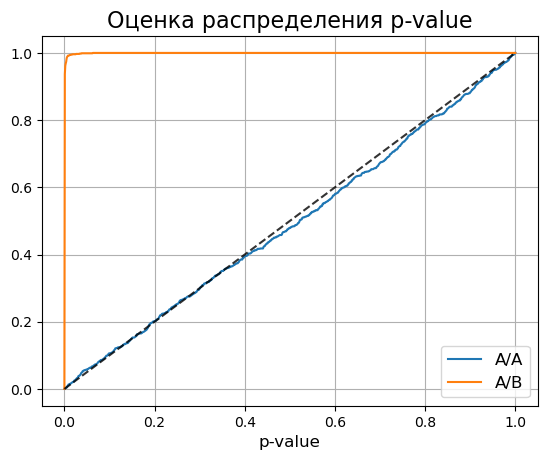

In [26]:
def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    for name, pvalues in dict_pvalues.items():
        Y = [np.mean(pvalues < x) for x in X]
        plt.plot(X, Y, label=name)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Оценка распределения p-value', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()
plot_pvalue_distribution({'A/A': pvalues_aa, 'A/B': pvalues_ab})

Критерий работает корректно.

### Задание 5 (1 балл)

Придумайте пример, в котором тест Манна-Уитни отвергает нулевую гипотезу о равенстве для распределений с равными медианами.

Постройте распределение p-value и изучите долю ошибок первого рода. Объясните, почему получился такой результат. Что тогда проверяет тест Манна-Уитни?

In [ ]:
import scipy.stats as sps


reject_cnt = 0

pvalue_values = []

for i in range(1000):
    # Генерируем 2 разных распределения, но с одинаковой медианой
    a = sps.uniform(loc=-1, scale=2).rvs(1000) #распределение со сзначениями от -1 до 1, где медиана равна 0
    b = sps.uniform(loc=-1000, scale=2000).rvs(1000) ##распределение со сзначениями от -1000 до 1000, где медиана равна 0
     
    # Считаем pvalue
    mann_pvalue = sps.mannwhitneyu(b, a, alternative='two-sided').pvalue
    pvalue_values.append(mann_pvalue)
     
    # отвергаем 0 гипотезу на уровне 5%
    if mann_pvalue < 0.05:
        reject_cnt += 1
        
print(f'Мы отвергнулу нулевую гипотезу: {reject_cnt} раз из 1000')

In [ ]:
plt.figure(figsize=(10, 6))  
plt.hist(pvalue_values, bins=20, edgecolor='blue')  
plt.xlabel('pvalue', fontsize=14)  
plt.ylabel('Частота', fontsize=14)
plt.title('Распределение pvalue', fontsize=14)
plt.xticks(fontsize=12)  
plt.yticks(fontsize=12)  

plt.show()


То есть, мы чаще чем в 5% случаев отвергаем нулевую гипотезу, что говорит о том, что критерий работает неверно.
Сам по себе критерий проверяет не равенство средних или медиан, а равенство распределений, то есть это критерий однородности данных. 

### Задание 6 (1.5 балл)

Вернемся к метрике revenue per user. Вам даны две очень похожие группы (файл `aa_test_logs.pkl`). 

1. Постройте распределение p-value для теста на равенство средних между группами.
2. Найдите, на каком уровне искусственно добавленного эффекта средняя выручка в группах станет различима. Ошибку первого рода считайте заданной и равной 0.05. Постройте график зависимости эффекта и ошибки 2 рода.

In [60]:
df = pd.read_pickle('aa_test_logs.pkl')
df

,user_id,dt,event,group,visit_id,cart_id,amount,num_items
0,DK452H,2023-12-23,first-visited,NaN,NaN,NaN,NaN,NaN
1,ED5SC3,2023-12-19,first-visited,NaN,NaN,NaN,NaN,NaN
2,ED5SC3,2023-12-29,shop-visit,second,npdt49xc6xb1fcbmlh0t,NaN,NaN,NaN
3,GD3FMD,2023-12-02,first-visited,NaN,NaN,NaN,NaN,NaN
4,GD3FMD,2023-12-02,shop-visit,second,kqsakfrjq5ys6kb0s8d0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
24388,X520K4,2023-12-22,first-visited,NaN,NaN,NaN,NaN,NaN
24389,X520K4,2023-12-26,shop-visit,first,mgx6hxqaecbfvp2s6gmm,NaN,NaN,NaN
24390,722YJR,2023-12-25,first-visited,NaN,NaN,NaN,NaN,NaN
24391,722YJR,2023-12-26,registered,second,NaN,NaN,NaN,NaN


### Задание 7 (1.5 балл)

На метрике revenue per user для разных групп (файл `ab_test_logs.pkl`) посчитайте мощность t-теста, бутстрапа и критерия Манна-Уитни при разных ошибках первого рода. Постройте график зависимости мощности от О1Р.

Какой тест получился мощнее остальных на уровне значимости 5%?

### Задание 8 (2 балла)

На данных `aa_test_logs.pkl` реализуйте А/А тесты через бутстрап и постройте распределение p-value. Какое распределение у вас получилось? Почему? Попробуйте доказать этот факт

In [74]:
df = pd.read_pickle('aa_test_logs.pkl')
df_paid = df[df['event'] == 'cart-paid']
df_paid_set = set(df_paid['cart_id'])
df = df[df['cart_id'].isin(df_paid_set)]
df = df[~df['group'].isna()]
df = df[~df['amount'].isna()]
df

,user_id,dt,event,group,visit_id,cart_id,amount,num_items
11,GD3FMD,2023-12-27,cart-add,second,dt8zlgsywf2qsmb8a2vm,l064p2ni6t,3738.829320,3.0
69,1APOVQ,2023-12-03,cart-add,first,2kycotfgnor2dowjzqq8,zwylg2ksra,367.905070,1.0
537,ITBI8P,2023-12-25,cart-add,first,0mqvkx0cm0l1n9xa1hjj,9besp16uw9,474.721301,1.0
707,9VP5DP,2023-12-26,cart-add,second,djg0b4icwh8rmjwmldit,714y6fgbky,1449.362216,1.0
810,U4VVCK,2023-12-22,cart-add,second,1s7kbyxdi8rkdwzp0q10,j4x5udec4z,2256.482364,2.0
...,...,...,...,...,...,...,...,...
23042,V69O1I,2023-12-20,cart-add,second,5o2s01cfhu2wrq3gf8s0,lgaevos3si,132.052211,1.0
23373,5U1HYX,2023-12-16,cart-add,first,xnq693n3byr0aeayq0vn,4ypml7dfkh,243.873093,1.0
23437,68QC4I,2023-12-19,cart-add,first,qdfwq0us4hcqq6j90vza,76om4qyedb,1551.348459,1.0
24336,WTC5FK,2023-12-15,cart-add,first,vwhua9vl1y3tpgvbx0af,lbpj69csgs,1465.910194,1.0


In [75]:
grouped = df.groupby(['user_id', 'group']).agg(
    total_amount=pd.NamedAgg(column='amount', aggfunc='sum'),
    count=pd.NamedAgg(column='amount', aggfunc='count')
).reset_index()

grouped['avg_check'] = grouped['total_amount']/grouped['count']


#удалим дубликаты юзеров
users = grouped.groupby('user_id')['group'].unique().reset_index()
users_with_both = users[users['group'].apply(lambda x: 'first' in x and 'second' in x)]['user_id']
filtered_df = grouped[~grouped['user_id'].isin(users_with_both)]
filtered_df

,user_id,group,total_amount,count,avg_check
0,0K6MB4,first,2929.244728,1,2929.244728
1,1APOVQ,first,367.905070,1,367.905070
2,2CRY8V,second,3308.235418,1,3308.235418
3,2EAWS2,second,262.375916,1,262.375916
4,31NFDI,second,143.251215,1,143.251215
...,...,...,...,...,...
75,X8V9FU,second,527.929600,1,527.929600
76,XSM5JX,first,658.538742,1,658.538742
77,YQ32WD,first,741.531825,1,741.531825
78,ZNTHVW,first,336.953403,1,336.953403


In [76]:
#разделим датасет на first и second
first = filtered_df[filtered_df['group'] == 'first']
second = filtered_df[filtered_df['group'] == 'second']


bootstrap_second_list = []
bootstrap_first_list = []

#забутсрапируем выборки
for _ in range(10000):
    bootstrap_second = np.random.choice(second['total_amount'].values, 
                                                len(second['total_amount'].values), True)
    bootstrap_first = np.random.choice(first['total_amount'].values, 
                                             len(first['total_amount'].values), True)

    bootstrap_second_list.append(bootstrap_second)
    bootstrap_first_list.append(bootstrap_first)

In [77]:
def plot_pvalue_ecdf(pvalues, title=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    if title:
        plt.suptitle(title)

    sns.histplot(pvalues, ax=ax1, bins=20, stat='density')
    ax1.plot([0,1],[1,1], 'k--')
    ax1.set_xlabel('p-value')

    sns.ecdfplot(pvalues, ax=ax2)
    ax2.set_ylabel('Probability')
    ax2.set_xlabel('p-value')
    ax2.grid()

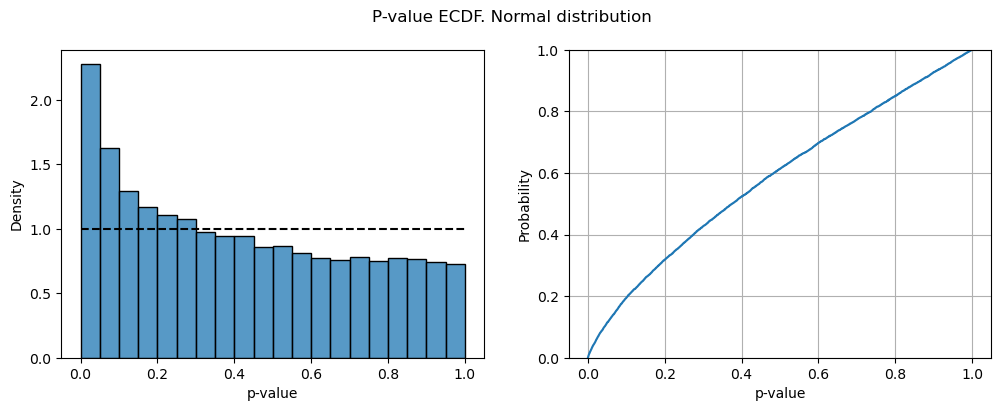

In [80]:
def get_pvalue_samples(a_samples, b_samples):
    pvalues = []
    for i in range(len(a_samples)):
        _, p = stats.ttest_ind(a_samples[i], b_samples[i])
        pvalues.append(p)
    return pvalues

pvalues = get_pvalue_samples(
    a_samples=bootstrap_first_list,
    b_samples=bootstrap_second_list
)

plot_pvalue_ecdf(pvalues, title='P-value ECDF. Normal distribution')